In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
from ibllib.atlas import AllenAtlas
from brainbox.io.spikeglx import Streamer
from neurodsp.voltage import destripe
from datetime import datetime
from pprint import pprint

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


/usr/local/lib/python3.10/dist-packages/ibllib/atlas/__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '
/usr/local/lib/python3.10/dist-packages/neurodsp/__init__.py:5: FutureWarning: neurodsp has been renamed to ibldsp and the old name will be deprecated on 01-Sep-2024.
  warn(
/usr/local/lib/python3.10/dist-packages/ibllib/atlas/atlas.py:13: DeprecationWarning: ibllib.atlas.atlas.AllenAtlas is deprecated. Use iblatlas.atlas.AllenAtlas instead
  warnings.warn(warning_text, DeprecationWarning)


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:19<00:00,  1.62it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:10<00:00,  2.80s/it]


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-313bf4cc-bc75-7bc6-3f39-5ed7faa3f30c)


In [4]:
!pip install captum
from captum.attr import IntegratedGradients
from captum.attr import LayerConductance
from captum.attr import NeuronConductance

from captum.attr import Saliency
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.8 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-many

In [5]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [6]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    # 'epochs':50,
    # 'save_dir':'/content/drive/MyDrive/Project/BrainRegionId/Project43',
}


In [7]:
# @title Load data
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
list_dict = torch.load(file_dir + '/list_dict.pt')

brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']
acronym_selec_list = list_dict['acronym_selec_list']

In [8]:
if len(brain_signal_lfp) == len(brain_region_index):
    print('Matched, no damage!')

Matched, no damage!


In [9]:
# acronym_interp = ['VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b']

In [10]:
ind = 0

key = 'stimOff_times'

model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Model/Allen'

if device.type != 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Allen_chance_{key}_{ind}.pth', map_location=torch.device('cpu'))
    Classifier_LC = torch.load(model_dir + f'/LC_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Allen_{key}_{ind}.pth', map_location=torch.device('cpu'))

elif device.type == 'cuda':

    Classifier_LCC = torch.load(model_dir + f'/LC_L_Allen_chance_{key}_{ind}.pth').to(device)
    Classifier_LC = torch.load(model_dir + f'/LC_L_Allen_{key}_{ind}.pth').to(device)


    Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_Allen_{key}_{ind}.pth').to(device)
    Classifier_ViT = torch.load(model_dir + f'/ViT_L_Allen_{key}_{ind}.pth').to(device)
    Classifier_RNN = torch.load(model_dir + f'/RNN_L_Allen_{key}_{ind}.pth').to(device)

subject_od_ind = torch.load(model_dir + f'/subject_od_ind_Allen_{key}{0}.pt')
subject_od_list = torch.load(model_dir + f'/subject_od_list_Allen_{key}{0}.pt')


In [11]:
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen(list_dict, subject_od_ind, key)

In [23]:
acronym_interp = ['VISp2/3', 'VISp5', 'DG-mo', 'CA1', 'CA2']

In [24]:
torch.cuda.empty_cache()
!nvidia-smi

Sun Jul  7 20:39:40 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   51C    P0              28W /  70W |    415MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [25]:
sample_num = 128
spectrogram_acronym = {}
for acronym_ii, acronym in enumerate(acronym_list):
    if acronym not in acronym_interp:
        continue
    test_ind_acronym_ii = np.intersect1d(np.argwhere(np.array(list_dict['brain_region_atlas']) == acronym).flatten(), test_ind)

    if len(test_ind_acronym_ii) < 1:
        # print(acronym)
        continue
    elif len(test_ind_acronym_ii) < sample_num:
        test_indiv = test_ind_acronym_ii

    elif len(test_ind_acronym_ii) >= sample_num:
        test_indiv = test_ind_acronym_ii[np.random.choice(len(test_ind_acronym_ii), sample_num, replace=False)]

    spectrogram = {}

    y_test = brain_region_index[test_indiv].to(device)
    x_test = lfp_spectro(brain_signal_lfp[test_indiv,:], spectro_args, train_args).requires_grad_()

    spectrogram_raw = x_test.detach().cpu().numpy().mean(axis=0)

    spectrogram['raw'] = spectrogram_raw[0, :, :]

    spectrogram_dl = {}
    Classifier_name = ['AnyNet', 'ViT', 'RNN']
    for Classifier_ii, Classifier in enumerate([Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
        Classifier.train()
        dl = DeepLift(Classifier)

        for interp_ii, interp in enumerate([dl]):

            if Classifier_name[Classifier_ii] == 'RNN':
                # py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
                attr, delta = interp.attribute(x_test.to(device).squeeze(1).permute(0, 2, 1), target=acronym_ii, return_convergence_delta=True)
                attr_sum = attr.permute(0, 2, 1).detach().cpu().numpy().sum(axis=0)

            elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
                # py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
                attr, delta = interp.attribute(x_test.to(device).squeeze(1).flatten(start_dim=1), target=acronym_ii, return_convergence_delta=True)
                attr = attr.detach().cpu().numpy()

            else:
                # py_test = Classifier(x_test.to(device))
                attr, delta = interp.attribute(x_test.to(device), target=acronym_ii, return_convergence_delta=True)
                attr_sum = attr.detach().cpu().numpy().sum(axis=0)[0, :, :]

            spectrogram_dl[Classifier_name[Classifier_ii]] = attr_sum / np.linalg.norm(attr_sum, ord=1)

    spectrogram['dl'] = spectrogram_dl
    spectrogram_acronym[acronym] = spectrogram

In [15]:
# delta_show = 1e-9
# acronym = 'CA1'
# plt.figure(figsize=(3, 5), dpi=200)
# plt.subplot(1, 4, 1)
# plt.imshow(np.log(spectrogram_acronym[acronym]['raw'] + delta_show), cmap='bwr')
# sns.despine()
# plt.yticks(np.int32(np.array([1, 4, 8, 12, 30, 70, 150, 200, 300, 400, 500]) / (500 / 224)), ['', '', '', '', '30', '70', '150', '200', '300', '400', '500'])
# plt.xticks(np.linspace(0, 28, 3), np.round((1 / 28) * np.linspace(0, 28, 3), 1))
# plt.xlabel('Time (s)')
# plt.ylabel('Frequence (Hz)')
# plt.show()

# plt.figure(figsize=(5, 5), dpi=200)
# plt.subplot(1, 4, 1)
# plt.imshow(np.log(spectrogram_acronym[acronym]['raw'] + delta_show)[0:7, :], cmap='bwr')
# sns.despine()
# plt.yticks(np.int32(np.array([1, 4, 8, 12,]) / (500 / 224)), ['1', '4', '8', '12',])
# plt.xticks(np.linspace(0, 6, 2), ['0', '0.25'])

# plt.show()


VISp5


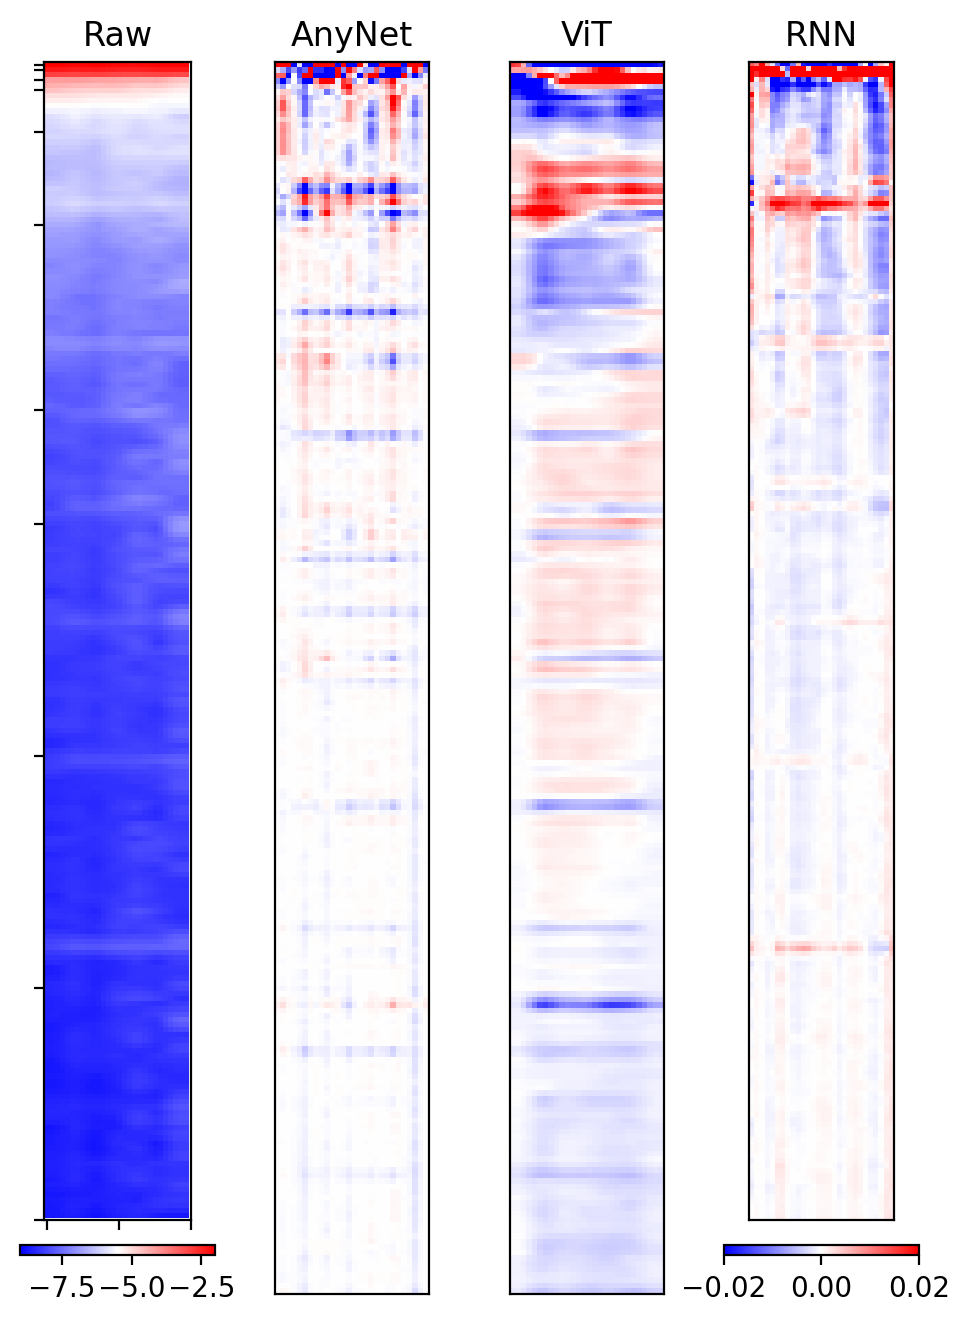

In [66]:
delta_show = 1e-9
acronym = 'VISp5'
print(acronym)
orient = 'horizontal'
scalefactor = 0.02
plt.figure(figsize=(5.8, 8), dpi=200)
plt.subplot(1, 4, 1)
plt.imshow(np.log(spectrogram_acronym[acronym]['raw'] + delta_show), vmin=-9.0, vmax=-2, cmap='bwr')
# plt.yticks(np.int32(np.array([1, 4, 8, 12, 30, 70, 150, 200, 300, 400, 500]) / (500 / 224)), ['', '', '', '', '30', '70', '150', '200', '300', '400', '500'])
# plt.xticks(np.linspace(0, 28, 3), np.round((1 / 28) * np.linspace(0, 28, 3), 1))
plt.yticks(np.int32(np.array([1, 4, 8, 12, 30, 70, 150, 200, 300, 400, 500]) / (500 / 224)), ['', '', '', '', '', '', '', '', '', '', ''])
plt.xticks(np.linspace(0, 28, 3), ['', '', ''])
# plt.xlabel('Time (s)')
# plt.ylabel('Frequence (Hz)')
plt.colorbar(orientation=orient, pad=0.02, shrink=1.0, fraction=0.04)
# plt.yticks([])
# plt.xticks([])
plt.title('Raw')
# plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(spectrogram_acronym[acronym]['dl']['AnyNet'], vmin=-scalefactor, vmax=scalefactor, cmap='bwr')
# plt.colorbar(orientation=orient, pad=0.02, shrink=1.0, fraction=0.04)
plt.title('AnyNet')
plt.yticks([])
plt.xticks([])
# plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(spectrogram_acronym[acronym]['dl']['ViT'], vmin=-scalefactor, vmax=scalefactor, cmap='bwr')
# plt.colorbar(orientation=orient, pad=0.02, shrink=1.0, fraction=0.02)
plt.title('ViT')
plt.yticks([])
plt.xticks([])
plt.subplot(1, 4, 4)
plt.imshow(spectrogram_acronym[acronym]['dl']['RNN'], vmin=-scalefactor, vmax=scalefactor, cmap='bwr')
plt.colorbar(orientation=orient, pad=0.02, shrink=1.0, fraction=0.04)
plt.title('RNN')
# sns.despine()
plt.yticks([])
plt.xticks([])
plt.show()

In [ ]:
acronym_interp0 = [ 'VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b']

In [ ]:
acronym_interp1 = ['DG-mo',
                    'DG-po',
                    'DG-sg',
                    'CA1',
                    'CA2',
                    'CA3',]

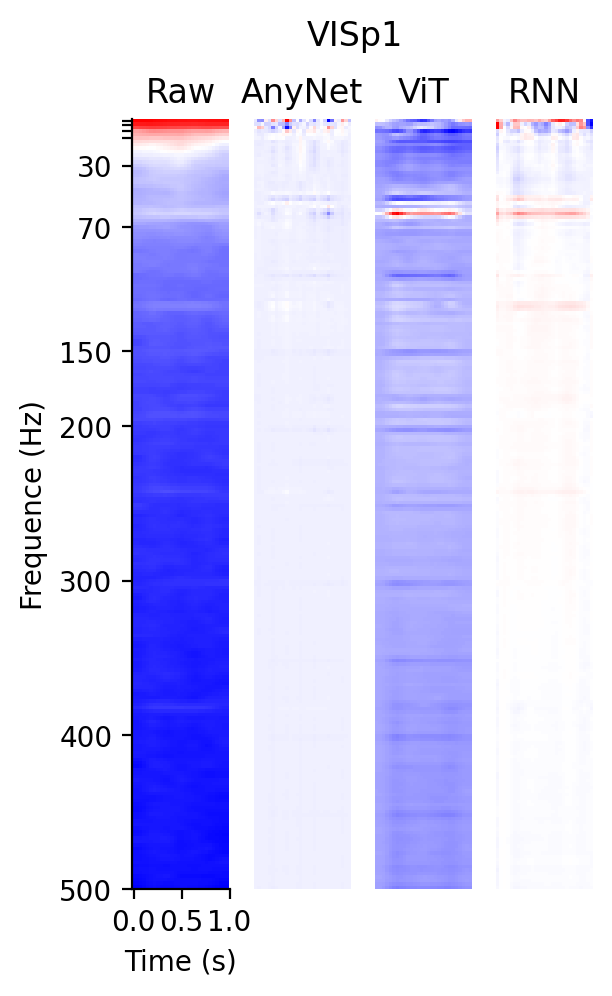

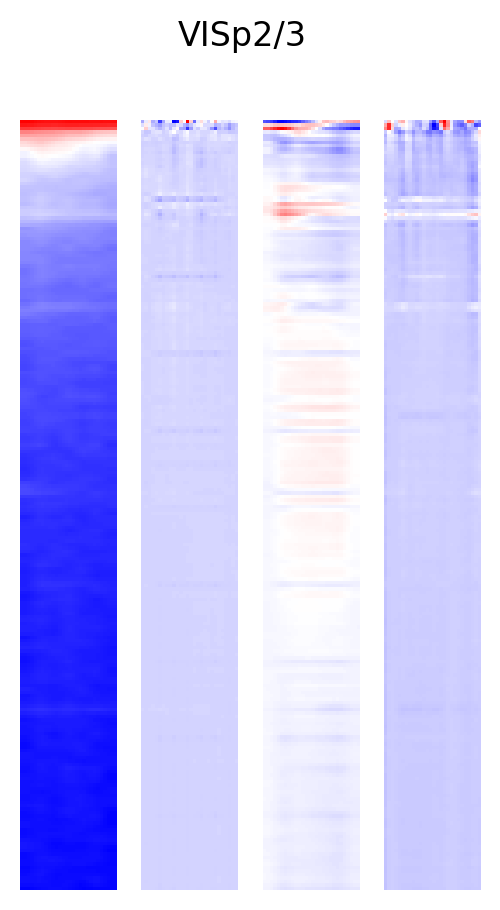

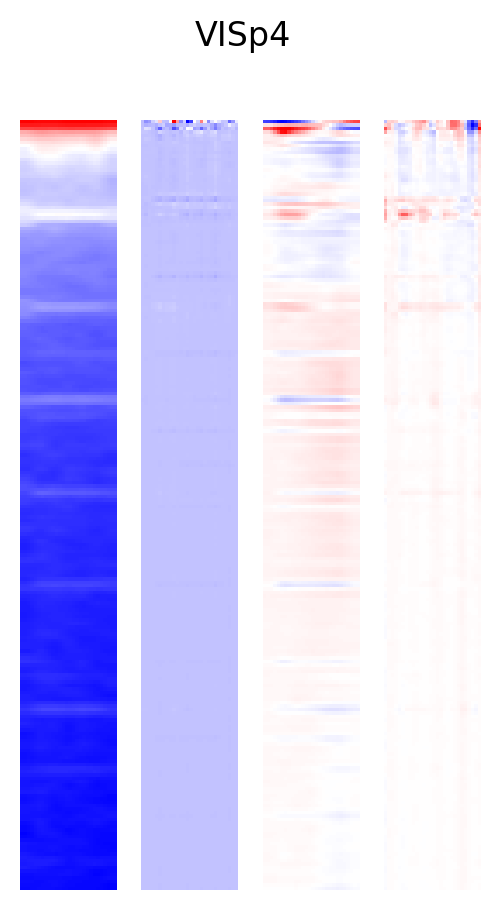

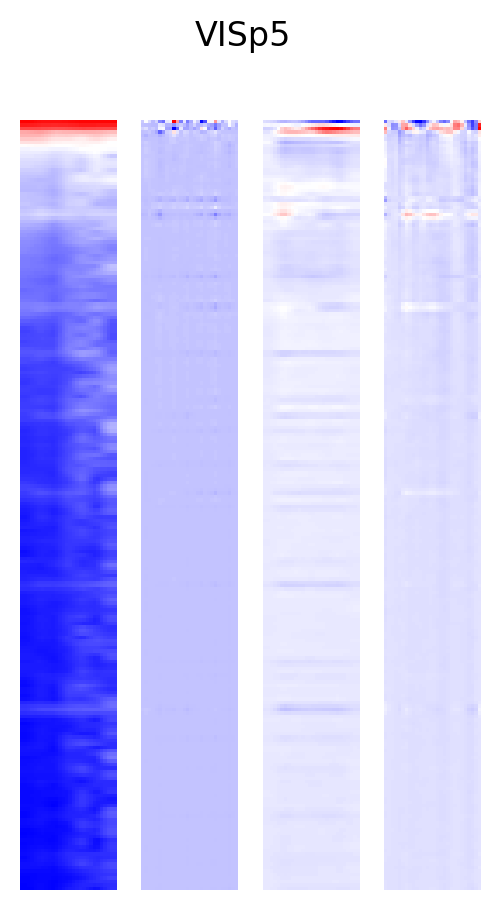

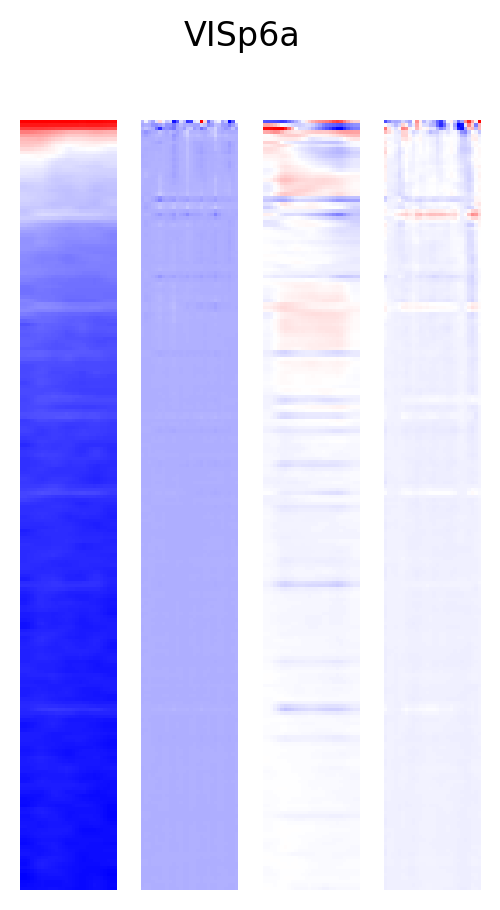

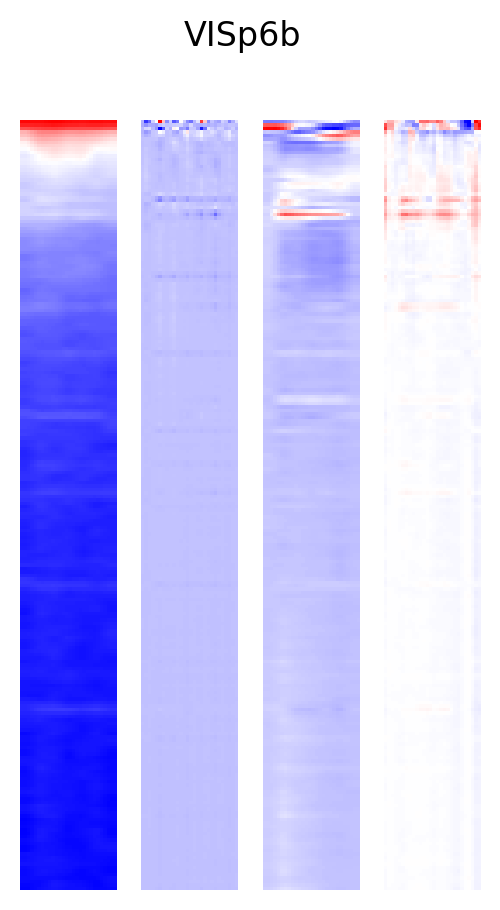

In [ ]:
delta_show = 1e-9
for acronym_ii, acronym in enumerate(acronym_interp0):
    # acronym = 'DG-mo'
    plt.figure(figsize=(3, 5), dpi=200)
    plt.subplot(1, 4, 1)
    plt.imshow(np.log(spectrogram_acronym[acronym]['raw'] + delta_show), cmap='bwr')
    if acronym_ii == 0:
        plt.yticks(np.int32(np.array([1, 4, 8, 12, 30, 70, 150, 200, 300, 400, 500]) / (500 / 224)), ['', '', '', '', '30', '70', '150', '200', '300', '400', '500'])
        plt.xticks(np.linspace(0, 28, 3), np.round((1 / 28) * np.linspace(0, 28, 3), 1))
        plt.xlabel('Time (s)')
        plt.ylabel('Frequence (Hz)')
        plt.title('Raw')
    else:
        plt.axis('off')
    plt.subplot(1, 4, 2)
    plt.imshow(spectrogram_acronym[acronym]['dl']['AnyNet'], cmap='bwr')
    if acronym_ii == 0:
        plt.title('AnyNet')
    plt.axis('off')
    plt.subplot(1, 4, 3)
    plt.imshow(spectrogram_acronym[acronym]['dl']['ViT'], cmap='bwr')
    if acronym_ii == 0:
        plt.title('ViT')
    plt.axis('off')
    plt.subplot(1, 4, 4)
    plt.imshow(spectrogram_acronym[acronym]['dl']['RNN'], cmap='bwr')
    if acronym_ii == 0:
        plt.title('RNN')
    sns.despine()
    plt.axis('off')
    plt.suptitle(acronym)
    plt.show()

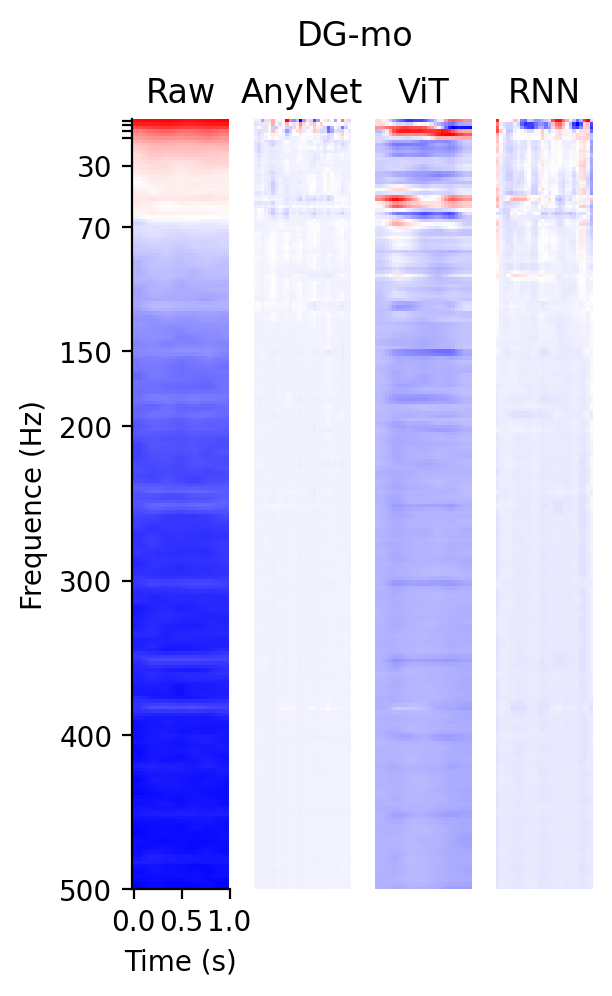

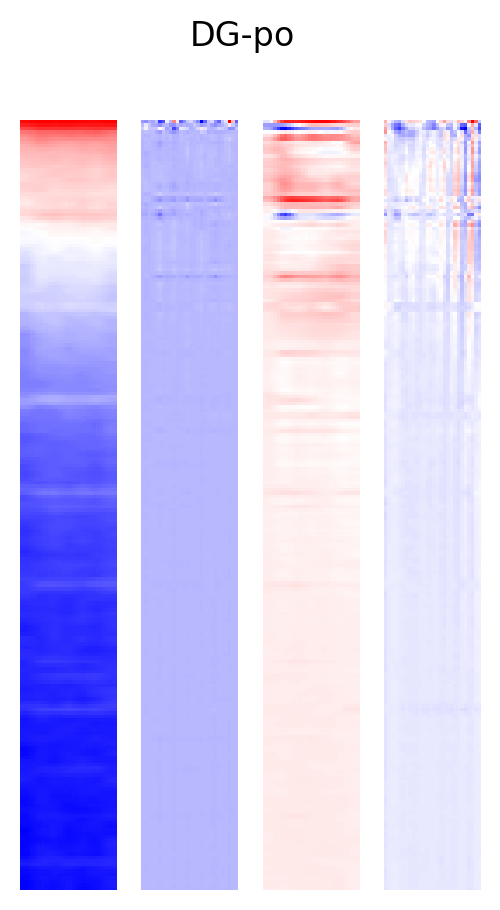

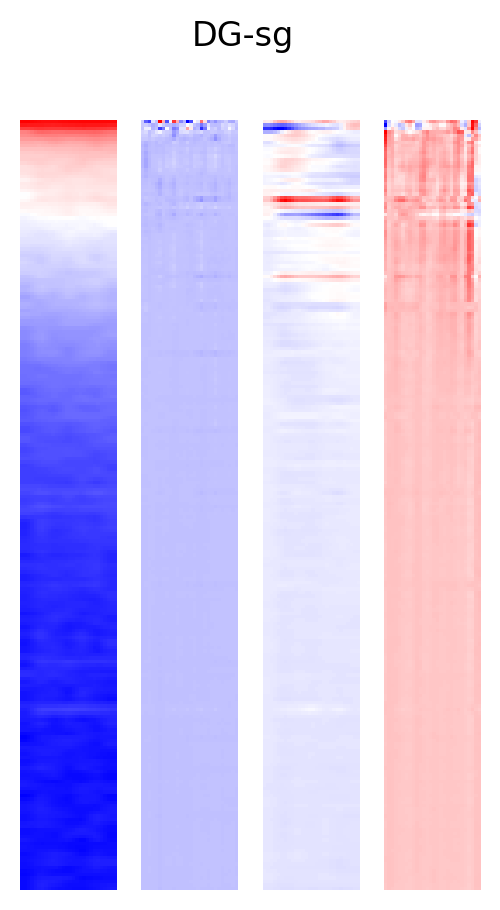

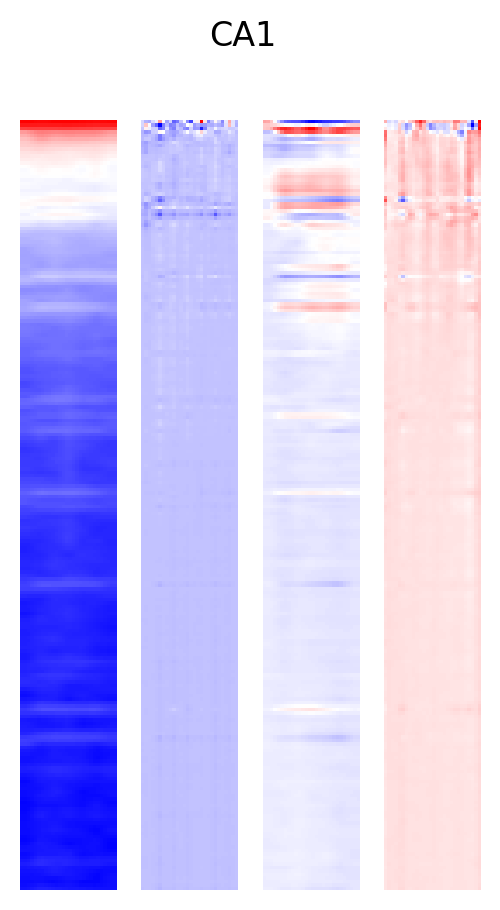

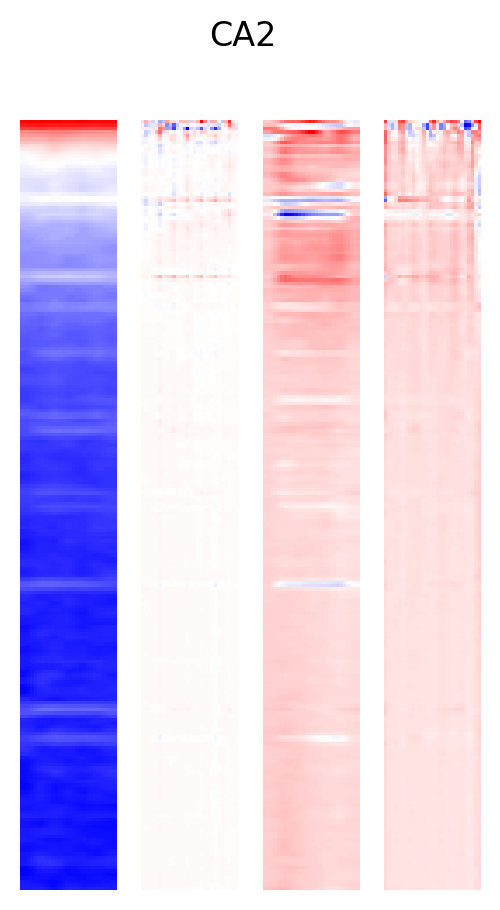

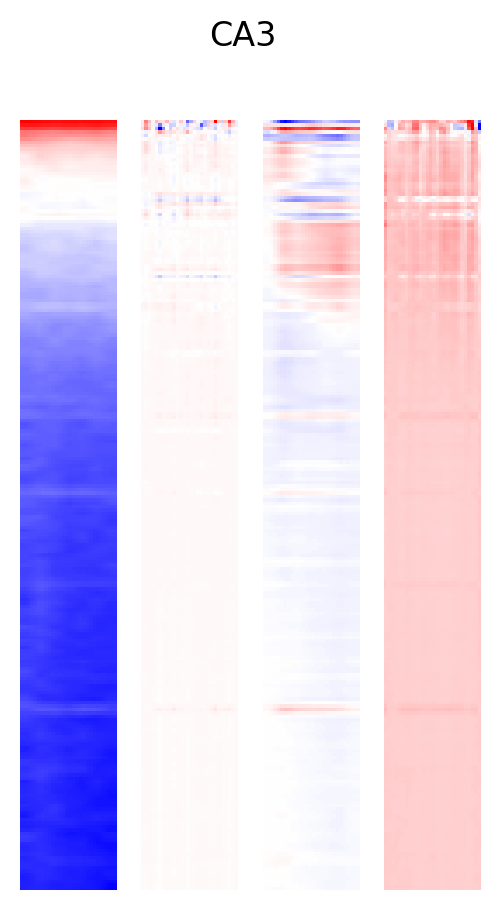

In [ ]:
delta_show = 1e-9
for acronym_ii, acronym in enumerate(acronym_interp1):
    # acronym = 'DG-mo'
    plt.figure(figsize=(3, 5), dpi=200)
    plt.subplot(1, 4, 1)
    plt.imshow(np.log(spectrogram_acronym[acronym]['raw'] + delta_show), cmap='bwr')
    if acronym_ii == 0:
        plt.yticks(np.int32(np.array([1, 4, 8, 12, 30, 70, 150, 200, 300, 400, 500]) / (500 / 224)), ['', '', '', '', '30', '70', '150', '200', '300', '400', '500'])
        plt.xticks(np.linspace(0, 28, 3), np.round((1 / 28) * np.linspace(0, 28, 3), 1))
        plt.xlabel('Time (s)')
        plt.ylabel('Frequence (Hz)')
        plt.title('Raw')
    else:
        plt.axis('off')
    plt.subplot(1, 4, 2)
    plt.imshow(spectrogram_acronym[acronym]['dl']['AnyNet'], cmap='bwr')
    if acronym_ii == 0:
        plt.title('AnyNet')
    plt.axis('off')
    plt.subplot(1, 4, 3)
    plt.imshow(spectrogram_acronym[acronym]['dl']['ViT'], cmap='bwr')
    if acronym_ii == 0:
        plt.title('ViT')
    plt.axis('off')
    plt.subplot(1, 4, 4)
    plt.imshow(spectrogram_acronym[acronym]['dl']['RNN'], cmap='bwr')
    if acronym_ii == 0:
        plt.title('RNN')
    sns.despine()
    plt.axis('off')
    plt.suptitle(acronym)
    plt.show()

In [ ]:
# delta_show = 1e-5

# plt.figure(figsize=(5, 5), dpi=200)
# for acronym_ind, acronym in enumerate(acronym_interp):
#     plt.subplot(1, 6, acronym_ind + 1)
#     plt.imshow(np.log(spectrogram_acronym[acronym]['raw'] + delta_show), cmap='bwr')
#     if acronym_ind != 0:
#         plt.axis('off')
#     else:
#         plt.yticks(np.linspace(0, 224, 15), np.int32((500 / 224) * np.linspace(0, 224, 15)))
#         plt.xticks(np.linspace(0, 32, 3), np.round((1 / 32) * np.linspace(0, 32, 3), 1))
#         plt.xlabel('Time (s)')
#         plt.ylabel('Frequence (Hz)')
#     plt.title(acronym)
#     sns.despine()
# plt.show()

# model_name = 'ViT'
# method = 'dl'
# plt.figure(figsize=(5, 5), dpi=200)
# for acronym_ind, acronym in enumerate(acronym_interp):
#     plt.subplot(1, 6, acronym_ind + 1)
#     plt.imshow(spectrogram_acronym[acronym][method][model_name], cmap='bwr')
#     if acronym_ind != 0:
#         plt.axis('off')
#     else:
#         plt.yticks(np.linspace(0, 224, 15), np.int32((500 / 224) * np.linspace(0, 224, 15)))
#         plt.xticks(np.linspace(0, 32, 3), np.round((1 / 32) * np.linspace(0, 32, 3), 1))
#         plt.xlabel('Time (s)')
#         plt.ylabel('Frequence (Hz)')
#     plt.title(acronym)
#     sns.despine()
# plt.show()


In [ ]:
# model_name = 'RNN'

# method = 'dl'
# plt.figure(figsize=(5, 5), dpi=200)
# for acronym_ind, acronym in enumerate(acronym_interp):
#     plt.subplot(1, 6, acronym_ind + 1)
#     plt.imshow(spectrogram_acronym[acronym][method][model_name], cmap='bwr')
#     if acronym_ind != 0:
#         plt.axis('off')
#     else:
#         plt.yticks(np.linspace(0, 224, 15), np.int32((500 / 224) * np.linspace(0, 224, 15)))
#         plt.xticks(np.linspace(0, 32, 3), np.round((1 / 32) * np.linspace(0, 32, 3), 1))
#         plt.xlabel('Time (s)')
#         plt.ylabel('Frequence (Hz)')
#     plt.title(acronym)
#     sns.despine()
# plt.show()

In [ ]:
# model_name = 'AnyNet'

# method = 'dl'
# plt.figure(figsize=(5, 5), dpi=200)
# for acronym_ind, acronym in enumerate(acronym_interp):
#     plt.subplot(1, 6, acronym_ind + 1)
#     plt.imshow(spectrogram_acronym[acronym][method][model_name], cmap='bwr')
#     if acronym_ind != 0:
#         plt.axis('off')
#     else:
#         plt.yticks(np.linspace(0, 224, 15), np.int32((500 / 224) * np.linspace(0, 224, 15)))
#         plt.xticks(np.linspace(0, 32, 3), np.round((1 / 32) * np.linspace(0, 32, 3), 1))
#         plt.xlabel('Time (s)')
#         plt.ylabel('Frequence (Hz)')
#     plt.title(acronym)
#     sns.despine()
# plt.show()

In [ ]:
# from google.colab import runtime
# runtime.unassign()